# 04. Feature Engineering

**Objectives of this Notebook:**
1. Build base features: total clicks, active days, last interaction, early engagement, submission delay, average score, learning stability.
2. Design compound behavioral features: `engagement_intensity`, `assessment_discipline`, `persistence_score`, `learning_risk_index`.
3. Standardize and select the final feature set for segmentation, prediction, and recommendation.

## 1: Initialization and Loading Cleaned Data

We will load the original data tables after cleaning from the `data/processed/` directory. This includes `student_profile.csv` (registration and personal information), `student_vle_summary.csv` (behavioral indicators from VLE logs like total clicks), and `assessment_performance.csv` (assessment scores and submission delay indicators).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Define paths
PROCESSED_DATA_DIR = '../data/processed/'

# Load main datasets
df_profile = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'student_profile.csv'))
df_vle_summary = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'student_vle_summary.csv'))
df_assessment = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'assessment_performance.csv'))

# Create base feature DataFrame by merging identifying keys
# We use inner join because we need complete behavior data for each module presentation
df_features = df_profile[['code_module', 'code_presentation', 'id_student', 'final_result', 'gender', 'highest_education', 'imd_band']].copy()

print("Shape of initial features target dataframe:", df_features.shape)
df_features.head()

Shape of initial features target dataframe: (28785, 7)


,code_module,code_presentation,id_student,final_result,gender,highest_education,imd_band
0,AAA,2013J,11391,Pass,M,HE Qualification,90-100%
1,AAA,2013J,28400,Pass,F,HE Qualification,20-30%
2,AAA,2013J,30268,Withdrawn,F,A Level or Equivalent,30-40%
3,AAA,2013J,31604,Pass,F,A Level or Equivalent,50-60%
4,AAA,2013J,32885,Pass,F,Lower Than A Level,50-60%


## 2: Building Base Features

In this section, we will construct basic features representing student behavior scattered across individual datasets and merge them into `df_features`.

**2.1. Interaction Behavior (VLE Features)**
From the click history data (`df_vle_summary`), we extract the following information: total clicks, first interaction date, last interaction date, and an estimation of the number of interaction days (a proxy for active days).

In [8]:
# Merge VLE summary features into our main features dataframe
df_features = pd.merge(df_features, df_vle_summary,
                       on=['id_student', 'code_module', 'code_presentation'], 
                       how='left')

# Handle missing values for students without any interaction (0 clicks)
vle_cols = ['total_clicks', 'max_clicks_per_day', 'avg_clicks']
df_features[vle_cols] = df_features[vle_cols].fillna(0)

# For first/last activity interaction, temporarily set as NaN before further imputation
# Create a variable counting active days (estimated via interaction rows = total_clicks / avg_clicks)
df_features['active_days'] = np.where(df_features['avg_clicks'] > 0, 
                                      df_features['total_clicks'] / df_features['avg_clicks'], 0).round()

# Learning stability = total learning span / active days
# Learning span = last interaction date - first interaction date
df_features['learning_span'] = df_features['last_activity_date'] - df_features['first_activity_date']
df_features['learning_span'] = df_features['learning_span'].apply(lambda x: x if x > 0 else 1).fillna(1)
df_features['learning_stability'] = df_features['active_days'] / df_features['learning_span']

# Early engagement -> if first activity <= 0 (before the course starts), engagement is early
df_features['early_engagement'] = np.where(df_features['first_activity_date'] <= 0, 1, 0)
df_features['early_engagement'] = df_features['early_engagement'].fillna(0)

print("Shape after merging VLE:", df_features.shape)
df_features.head(3)

Shape after merging VLE: (28785, 16)


,code_module,code_presentation,id_student,final_result,gender,highest_education,imd_band,total_clicks,avg_clicks,max_clicks_per_day,first_activity_date,last_activity_date,active_days,learning_span,learning_stability,early_engagement
0,AAA,2013J,11391,Pass,M,HE Qualification,90-100%,934.0,4.765306,76.0,-5.0,253.0,196.0,258.0,0.759690,1
1,AAA,2013J,28400,Pass,F,HE Qualification,20-30%,1435.0,3.337209,23.0,-10.0,239.0,430.0,249.0,1.726908,1
2,AAA,2013J,30268,Withdrawn,F,A Level or Equivalent,30-40%,281.0,3.697368,23.0,-10.0,12.0,76.0,22.0,3.454545,1


**2.2. Assessment Scores and Submission Delay (Assessment Features)**
Assignments and scores (Assessment) reflect student performance on the system. We will link the student's submission time (`date_submitted`) and the original deadline (`date`) in `assessments_clean.csv` to calculate the submission delay.

In [9]:
df_assessment_info = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'assessments_clean.csv'))

# Merge the submission record with the assignment deadline data
df_assess_merge = pd.merge(df_assessment, df_assessment_info[['id_assessment', 'date']], 
                           on='id_assessment', how='left')

# Drop those without a valid submission date
df_assess_merge = df_assess_merge.dropna(subset=['date_submitted', 'date'])

# Calculate submission delay: delay > 0 means late, delay <= 0 means early or on time
df_assess_merge['submission_delay'] = df_assess_merge['date_submitted'] - df_assess_merge['date']

# Create aggregated metrics for each student per module (Avg Score, Max Score, Avg Delay)
assess_features = df_assess_merge.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    avg_score=('score', 'mean'),
    max_score=('score', 'max'),
    avg_submission_delay=('submission_delay', 'mean'),
    total_assignments_submitted=('id_assessment', 'count')
).reset_index()

# Merge into our main features dataframe
df_features = pd.merge(df_features, assess_features, 
                       on=['id_student', 'code_module', 'code_presentation'], 
                       how='left')

# Handle missing values (e.g., students who failed or did not submit any assignments)
df_features['avg_score'] = df_features['avg_score'].fillna(0)
df_features['max_score'] = df_features['max_score'].fillna(0)
df_features['avg_submission_delay'] = df_features['avg_submission_delay'].fillna(0) # assume no submission / on time
df_features['total_assignments_submitted'] = df_features['total_assignments_submitted'].fillna(0)

display(df_features[['id_student', 'code_module', 'avg_score', 'avg_submission_delay']].head(5))

,id_student,code_module,avg_score,avg_submission_delay
0,11391,AAA,82.0,-1.8
1,28400,AAA,66.4,0.0
2,30268,AAA,0.0,0.0
3,31604,AAA,76.0,-2.0
4,32885,AAA,54.4,11.4


## 3: Designing Aggregated/Compound Behavioral Features

This step combines base features to create more sophisticated indicators that directly impact recommendations and predictions. Specifically:
- **Engagement Intensity**: The intensity of interaction = Total clicks / active days (equivalent to clicks per day).
- **Assessment Discipline**: Calculated by awarding or penalizing based on the history of late/early submissions.
- **Persistence Score**: Based on the number of fully completed assignments and the duration of participation in the module compared to its overall length.
- **Learning Risk Index (LRI)**: A composite risk indicator. A high risk score occurs when there's low interaction, poor assignment performance, and frequent late submissions. This can act as a `target proxy`.

In [10]:
# 1. Engagement Intensity
# Formula: total clicks / active days (corresponding to clicks per active day)
# If active_days = 0, set to 0.
df_features['engagement_intensity'] = np.where(
    df_features['active_days'] > 0, 
    df_features['total_clicks'] / df_features['active_days'], 
    0
)

# 2. Assessment Discipline 
# Based on avg score and average delay (lower/negative delay -> high discipline)
# High score, early/on-time submission -> max discipline.
max_delay = df_features['avg_submission_delay'].max()
min_delay = df_features['avg_submission_delay'].min()
if max_delay - min_delay == 0: delay_range = 1 
else: delay_range = max_delay - min_delay

# Normalize delay from 0 (late) -> 1 (early/on time)
df_features['discipline_score'] = 1 - (df_features['avg_submission_delay'] - min_delay) / delay_range

# Calculate discipline weight based on delay + number of submitted assignments
df_features['assessment_discipline'] = df_features['discipline_score'] * (df_features['total_assignments_submitted'] / (df_features['total_assignments_submitted'].max() + 1))


# 3. Persistence Score
# Learning span relative to expected course length
# Assume average course length is 250 days
expected_course_length = 250 
persistence_length = df_features['learning_span'] / expected_course_length

# Persistence = Based on early engagement + long span
df_features['persistence_score'] = (persistence_length * 0.5) + (df_features['early_engagement'] * 0.5)
# Cap persistence at max 1.0
df_features['persistence_score'] = df_features['persistence_score'].clip(upper=1.0)


# 4. Learning Risk Index (LRI)
# LRI = Inverse of (Normalized Avg Score) + (Normalized Engagement) - Penalty (Late Submissions)
# A student with high scores and high interaction -> risk near 0 (lowest)
# A student with 0 score, low interaction, late submissions -> risk approaches 1.
avg_score_norm = df_features['avg_score'] / 100.0  # Assumes max score is 100
eng_max = df_features['engagement_intensity'].max() 
eng_intensity_norm = df_features['engagement_intensity'] / eng_max

df_features['learning_risk_index'] = 1 - (0.5 * avg_score_norm + 0.3 * eng_intensity_norm + 0.2 * df_features['assessment_discipline'])
df_features['learning_risk_index'] = df_features['learning_risk_index'].clip(lower=0.0, upper=1.0)

# Review results: Example of Learning Risk Index by Final Result
print("Learning Risk Index Statistics:")
display(df_features.groupby('final_result')['learning_risk_index'].mean())

Learning Risk Index Statistics:


final_result
Distinction    0.446994
Fail           0.671164
Pass           0.512777
Withdrawn      0.816332
Name: learning_risk_index, dtype: float64

## 4: Standardization, Cleaning, and Saving the Final Feature Set
1. Remove junk variables (IDs or textual data not needed for modeling, or converted into categoricals).
2. Standardize skewed distributions to a 0-1 scale (e.g., using MinMaxScaler if necessary).
3. Save the resulting dataset to `features_final.csv` for use in machine learning models in `05_` and `10_`.

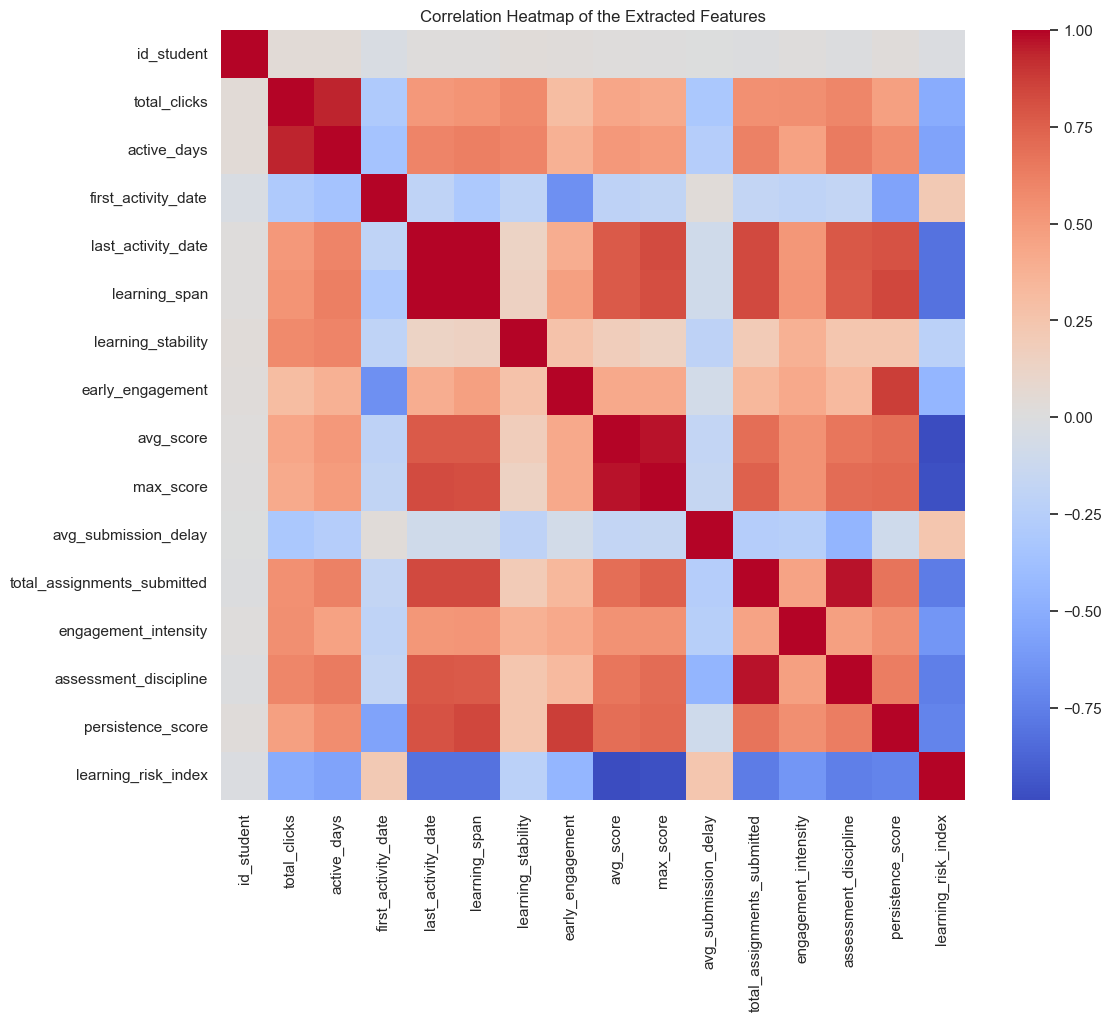

Data saved successfully with 19 features and 28785 records.
Path: ../data/processed/features_final.csv


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Select key variables as inputs for future models
model_features = [
    'id_student', 'code_module', 'code_presentation', 'final_result',
    # Base features
    'total_clicks', 'active_days', 'first_activity_date', 'last_activity_date', 
    'learning_span', 'learning_stability', 'early_engagement',
    'avg_score', 'max_score', 'avg_submission_delay', 'total_assignments_submitted',
    
    # Compound behavioral features
    'engagement_intensity', 'assessment_discipline', 'persistence_score', 'learning_risk_index'
]

df_final = df_features[model_features].copy()

# Instead of scaling right away, we should fill NAs properly to avoid model errors
df_final.fillna(0, inplace=True)

# Display the correlation between final_result and analytical features
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_final.select_dtypes(include=[np.number]).columns
if 'final_result' in df_final.columns:
    df_numeric = df_final[numeric_cols].copy()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm')
    plt.title('Correlation Heatmap of the Extracted Features')
    plt.show()

# Save output to serve subsequent modeling notebooks
OUTPUT_FILE = os.path.join(PROCESSED_DATA_DIR, 'features_final.csv')
df_final.to_csv(OUTPUT_FILE, index=False)

print(f"Data saved successfully with {df_final.shape[1]} features and {df_final.shape[0]} records.")
print(f"Path: {OUTPUT_FILE}")